In [7]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv("customer_complaints_1.csv")

#  column names
df.columns = df.columns.str.strip()
print("Columns:", df.columns)

# Preprocessing
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)
    
# (uses first column automatically)
df['clean_text'] = df[df.columns[0]].apply(preprocess)  


# TF-IDF
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df['clean_text'])

# Clustering
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X)

# Show result
print(df[[df.columns[0], 'Cluster']].head())

# Top words per cluster
print("\nTop terms per cluster:")
terms = vectorizer.get_feature_names_out()
order_centroids = km.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    print(f"\nCluster {i}:")
    for ind in order_centroids[i, :10]:
        print(terms[ind])

Columns: Index(['author', 'posted_on', 'rating', 'text'], dtype='object')
                        author  Cluster
0  Alantae of Chesterfeild, MI        1
1     Vera of Philadelphia, PA        1
2  Sarah of Rancho Cordova, CA        1
3     Dennis of Manchester, NH        1
4         Ryan of Bellevue, WA        0

Top terms per cluster:

Cluster 0:
wa
marc
bellingham
bellevue
ryan
ut
thornton
tyneshia
tx
tn

Cluster 1:
al
thornton
meta
lori
huntsville
mobile
terri
tn
shira
vera

Cluster 2:
ga
lawrenceville
donnie
kristy
alpharetta
tx
ut
tyneshia
wa
vera


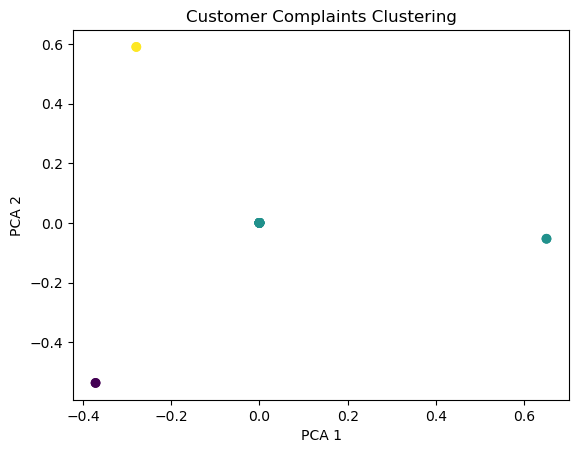

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Convert to dense
X_dense = X.toarray()

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'])
plt.title("Customer Complaints Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()